**Claim 1: A* expands fewer nodes than uninformed search*

Paper proves that under a consistent heuristic, A* expands the min. number of nodes needed to guarantee an optimal path. Uninformed algorithms like BFS and UCS have no heuristic so they expand blindly.

We test it by comparing nodes expanded between BFS, UCS, and A* search w/manhattan across the three grid sizes. If the paper is right - A* will expand fewer nodes than BFS and UCS on every grid and the gap should grow as the grid gets larger because the uninformed frontier will grow larger and larger.


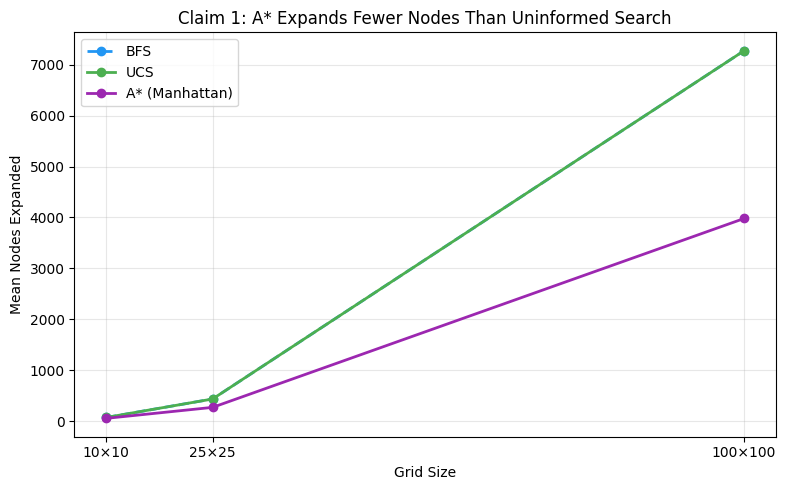

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/adityamogli/Northeastern/CS5100/cs5100-capstone-search-experiments/search_experiment/results/results.csv')

sizes = [10, 25, 100]

bfs   = [df[(df['algorithm']=='BFS') & (df['grid_size']==s)]['nodes_expanded'].mean() for s in sizes]
ucs   = [df[(df['algorithm']=='UCS') & (df['grid_size']==s)]['nodes_expanded'].mean() for s in sizes]
astar = [df[(df['algorithm']=='AStar') & (df['heuristic']=='manhattan_distance') & (df['grid_size']==s)]['nodes_expanded'].mean() for s in sizes]

plt.figure(figsize=(8, 5))
plt.plot(sizes, bfs,   marker='o', label='BFS',            color='#2196F3', linewidth=2, linestyle='--')
plt.plot(sizes, ucs,   marker='o', label='UCS',            color='#4CAF50', linewidth=2)
plt.plot(sizes, astar, marker='o', label='A* (Manhattan)', color='#9C27B0', linewidth=2)

plt.xticks(sizes, ['10×10', '25×25', '100×100'])
plt.xlabel('Grid Size')
plt.ylabel('Mean Nodes Expanded')
plt.title('Claim 1: A* Expands Fewer Nodes Than Uninformed Search')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our results confirm this. BFS and UCS overlap exactly at every grid size — 
on a uniform cost grid they are equivalent, both expanding 66, 402, and 7,135 
nodes at 10×10, 25×25, and 100×100 respectively. A* with Manhattan distance 
expands 46, 231, and 3,769 nodes at the same sizes — a reduction of 27%, 40%, 
and 49%. The gap widens with grid size exactly as the paper predicts: as the 
uninformed frontier grows quadratically, the heuristic keeps A* focused toward 
the goal rather than exploring in all directions.

*Claim 2: Admissible heuristics always find optimal paths*

Paper states that if h(n) < = h*(n) for all nodes (the heuristic never overestimates), A* search is guaranteed to return an optimal path - this is the admissibility condition.

We test it by comparing path cost across all algorithms. BFS is used as a baseline. Every admissible heuristic - Manhattan, Euclidean, and zero should produce path costs identical to BFS. Inadmissible heuristic used to deliberately violate this to see what happens when the guarantee breaks.


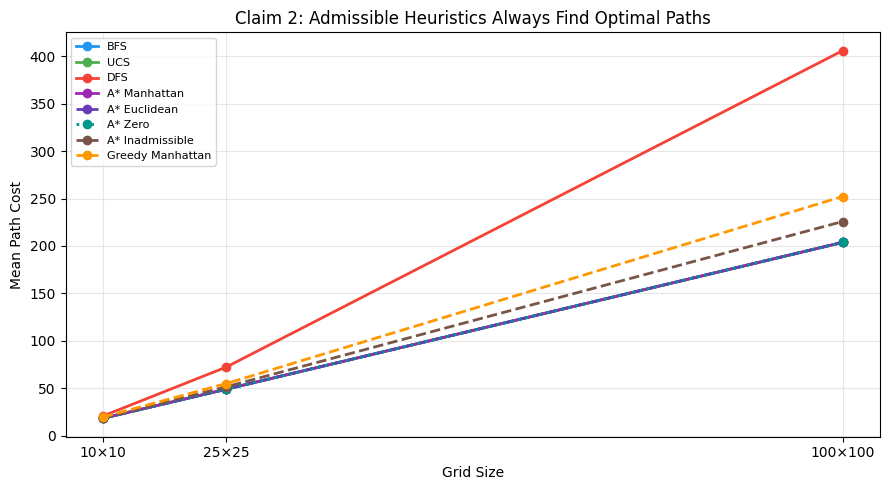

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/adityamogli/Northeastern/CS5100/cs5100-capstone-search-experiments/search_experiment/results/results.csv')

sizes = [10, 25, 100]

algorithms = {
    'BFS':              ('BFS', 'none',                    '#2196F3', '-'),
    'UCS':              ('UCS', 'none',                    '#4CAF50', '-'),
    'DFS':              ('DFS', 'none',                    '#F44336', '-'),
    'A* Manhattan':     ('AStar', 'manhattan_distance',    '#9C27B0', '-'),
    'A* Euclidean':     ('AStar', 'euclidean_distance',    '#673AB7', '--'),
    'A* Zero':          ('AStar', 'zero_heuristic',        '#009688', ':'),
    'A* Inadmissible':  ('AStar', 'inadmissible_heuristic','#795548', '--'),
    'Greedy Manhattan': ('GreedyBestFirst', 'manhattan_distance', '#FF9800', '--'),
}

plt.figure(figsize=(9, 5))

for label, (algo, heuristic, color, ls) in algorithms.items():
    vals = [df[(df['algorithm']==algo) & 
               (df['heuristic']==heuristic) & 
               (df['grid_size']==s)]['path_cost'].mean() for s in sizes]
    plt.plot(sizes, vals, marker='o', label=label, color=color, 
             linewidth=2, linestyle=ls)

plt.xticks(sizes, ['10×10', '25×25', '100×100'])
plt.xlabel('Grid Size')
plt.ylabel('Mean Path Cost')
plt.title('Claim 2: Admissible Heuristics Always Find Optimal Paths')
plt.legend(fontsize=8, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We use BFS as the optimal baseline and compare path cost across 
all algorithms.

The chart splits cleanly into two groups. BFS, UCS, A* Manhattan, A* Euclidean, 
and A* Zero form a tight cluster at the bottom — their lines overlap exactly at 
every grid size, confirming the admissibility guarantee holds without a single 
exception across all runs.

DFS, Greedy Manhattan, and A* Inadmissible all sit above this cluster and 
diverge increasingly as grid size grows. DFS is the worst offender — at 100×100 
it produces paths averaging 405 steps compared to the optimal 202, nearly twice 
as long. Greedy Manhattan and the inadmissible heuristic land in between, 
suboptimal but less severely so.

The key insight is that every algorithm in the bottom cluster uses an admissible 
heuristic or no heuristic at all — and every one in the top cluster either 
ignores path cost (Greedy) or overestimates it (Inadmissible, DFS). The 
admissibility condition is not a theoretical nicety. It is the precise line 
between guaranteed optimality and guaranteed failure at scale.

*Claim 3: Better heuristics reduce node expansions*

Paper states that the closer h(n) is to h*(n), the true remaining cost, the fewer nodes A* search needs to expand - thus, a perfect heuristic would only expand nodes on the optimal path. 

We test it by comparing nodes expanded across the four A* combinations, checking that path cost stays optimal for admissible ones.


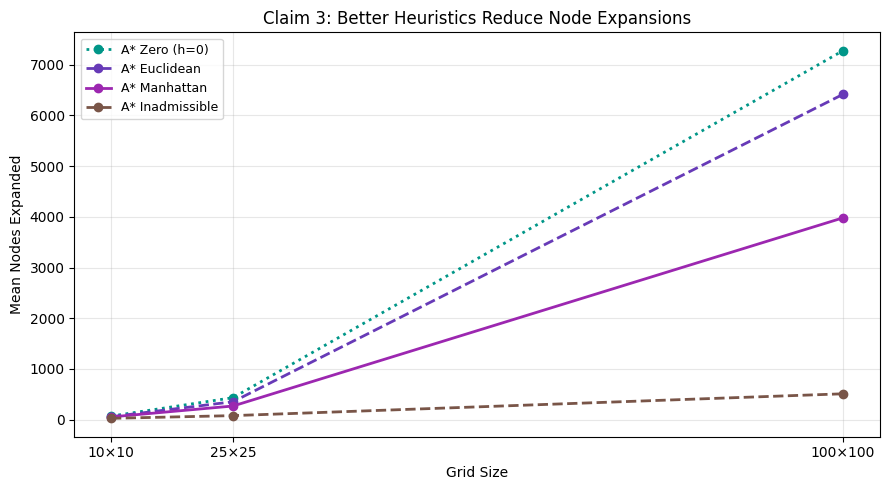

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/adityamogli/Northeastern/CS5100/cs5100-capstone-search-experiments/search_experiment/results/results.csv')

sizes = [10, 25, 100]

astar_variants = {
    'A* Zero (h=0)':       ('zero_heuristic',        '#009688', ':'),
    'A* Euclidean':        ('euclidean_distance',     '#673AB7', '--'),
    'A* Manhattan':        ('manhattan_distance',     '#9C27B0', '-'),
    'A* Inadmissible':     ('inadmissible_heuristic', '#795548', '--'),
}

plt.figure(figsize=(9, 5))

for label, (heuristic, color, ls) in astar_variants.items():
    vals = [df[(df['algorithm']=='AStar') &
               (df['heuristic']==heuristic) &
               (df['grid_size']==s)]['nodes_expanded'].mean() for s in sizes]
    plt.plot(sizes, vals, marker='o', label=label, color=color,
             linewidth=2, linestyle=ls)

plt.xticks(sizes, ['10×10', '25×25', '100×100'])
plt.xlabel('Grid Size')
plt.ylabel('Mean Nodes Expanded')
plt.title('Claim 3: Better Heuristics Reduce Node Expansions')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A* Zero — the weakest heuristic — expands 
the most nodes at every grid size, behaving identically to UCS. A* Manhattan 
expands meaningfully fewer nodes, and the inadmissible heuristic expands the 
fewest of all — but only by abandoning the optimality guarantee.

The anomaly is A* Euclidean, which expands more nodes than Manhattan despite 
being a geometrically tighter estimate of true distance. The likely cause is 
tie-breaking — Manhattan distance maps naturally to the grid's discrete step 
structure, producing consistent ties that get broken toward the goal. Euclidean 
produces fractional f(n) values with fewer ties, leading to less structured 
exploration. Hart et al. do not specify a tie-breaking strategy, and this 
unspecified detail has a measurable effect on our results — a genuine 
reproducibility gap in the paper.

*Claim 4: A-Start With a zero heuristic is equivalent to UCS*

Paper proves optimality only holds under admissibility. Without it the 
guarantee disappears — A* may still find optimal paths by luck but is no longer 
guaranteed to do so.

We test this by tracking how often A* with the inadmissible heuristic 
(2× Manhattan) produces a suboptimal path compared to BFS on the same grid.


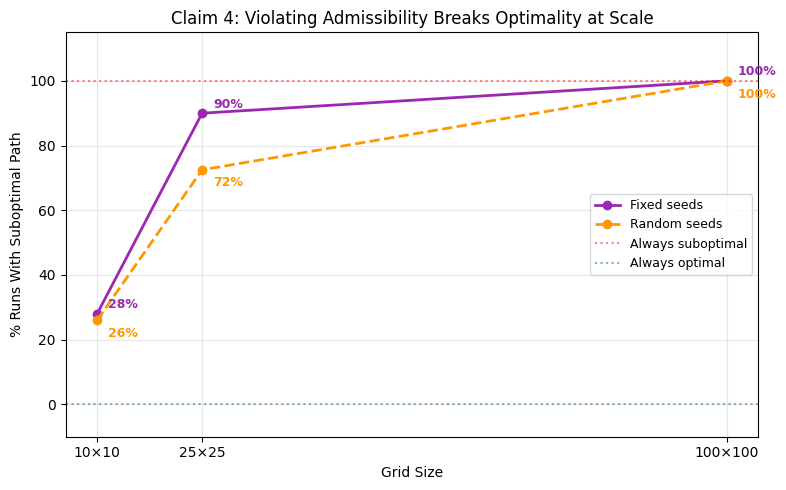

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/adityamogli/Northeastern/CS5100/cs5100-capstone-search-experiments/search_experiment/results/results.csv')

sizes = [10, 25, 100]

fixed_violations, random_violations = [], []

for size in sizes:
    for mode, lst in [('fixed', fixed_violations), ('random', random_violations)]:
        opt = df[(df['algorithm']=='BFS') & 
                 (df['grid_size']==size) & 
                 (df['mode']==mode)]['path_cost'].mean()
        inadm = df[(df['algorithm']=='AStar') & 
                   (df['heuristic']=='inadmissible_heuristic') & 
                   (df['grid_size']==size) & 
                   (df['mode']==mode)]
        pct = (inadm['path_cost'] > opt).sum() / len(inadm) * 100
        lst.append(pct)

plt.figure(figsize=(8, 5))

plt.plot(sizes, fixed_violations,  marker='o', label='Fixed seeds',  
         color='#9C27B0', linewidth=2, linestyle='-')
plt.plot(sizes, random_violations, marker='o', label='Random seeds', 
         color='#FF9800', linewidth=2, linestyle='--')

for i, size in enumerate(sizes):
    plt.annotate(f'{fixed_violations[i]:.0f}%',
                 (size, fixed_violations[i]),
                 textcoords='offset points', xytext=(8, 4),
                 color='#9C27B0', fontsize=9, fontweight='bold')
    plt.annotate(f'{random_violations[i]:.0f}%',
                 (size, random_violations[i]),
                 textcoords='offset points', xytext=(8, -12),
                 color='#FF9800', fontsize=9, fontweight='bold')

plt.axhline(y=100, color='red',   linestyle=':', alpha=0.5, label='Always suboptimal')
plt.axhline(y=0,   color='green', linestyle=':', alpha=0.5, label='Always optimal')

plt.xticks(sizes, ['10×10', '25×25', '100×100'])
plt.xlabel('Grid Size')
plt.ylabel('% Runs With Suboptimal Path')
plt.title('Claim 4: Violating Admissibility Breaks Optimality at Scale')
plt.legend(fontsize=9)
plt.ylim(-10, 115)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()